# Probar Web API ya creada en forma pública para utilizar modelo entrenado para naves de StarWars con TensorFlow+Keras usando Flask y ngrok

In [ ]:
#@title Accede al Drive

# Acceder al drive
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


Archivo de datos  naves.csv  cargado


GridBox(children=(Label(value='Ajuste para configuración de los Datos: '), Dropdown(description='Atributo clas…



> Datos enviados:  [{'Manufacturer': 12.0, 'Length': 230.0, 'Cargo Capacity': 2000000.0, 'Hyperdrive Multiplier': 1.0, 'Speed': 39.0, 'Hull': 353.0, 'Special Features': 0.0, 'Shields': 300.0, 'Onboard Craft': 0.0, 'LASER CANNONS': 0.0, 'TURBOLASER CANNONS': 0.0, 'ION LAUNCHER': 0.0, 'GENERAL PURPOSE LAUNCHER': 0.0, 'TURBOLASER TURRETS': 0.0, 'BLASTER CANNONS': 0.0, 'LASER TURRETS': 0.0, 'TRACTOR BEAM PROJECTORS': 0.0, 'TURBOLASER BATTERIES': 0.0, 'ION CANNONS': 0.0, 'TORPEDO LAUNCHER': 0.0, 'GRAVITY WELL PROJECTORS': 0.0, 'SUPERLASERS': 0.0, 'BLASTER TURRETS': 0.0, 'TORPEDO': 0.0, 'ORBITAL MINE': 0.0, 'THERMAL DETONATOR LAUNCHER': 0.0, 'TURBOLASER': 0.0, 'ION TURRETS': 0.0, 'SPACE BOMB': 0.0, 'ION BATTERIES': 0.0, 'HULL-CUTTING AIRLOCKS': 0.0, 'EMP CANNONS': 0.0, 'TORPEDO TUBES': 0.0}]
+ Clase Real:  Medium Ships
	 https://c8bc-34-181-158-66.ngrok-free.app/SWdatos  [ {'content-type': 'application/json', 'ngrok-skip-browser-warning': '69420'} - [{"Manufacturer": 12.0, "Length": 230.0,

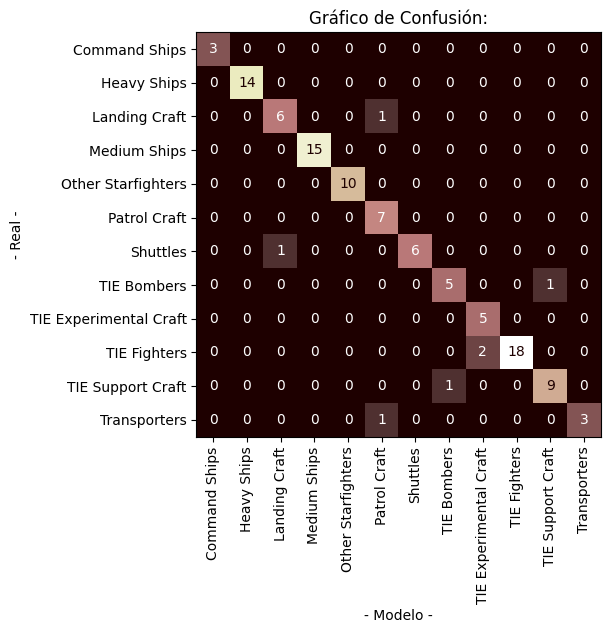



> Datos enviados:  [{'Manufacturer': 17.0, 'Length': 7.8, 'Cargo Capacity': 150.0, 'Hyperdrive Multiplier': 4.0, 'Speed': 95.0, 'Hull': 15.0, 'Special Features': 0.0, 'Shields': 21.0, 'Onboard Craft': 0.0, 'LASER CANNONS': 10.0, 'TURBOLASER CANNONS': 0.0, 'ION LAUNCHER': 2.0, 'GENERAL PURPOSE LAUNCHER': 0.0, 'TURBOLASER TURRETS': 0.0, 'BLASTER CANNONS': 0.0, 'LASER TURRETS': 0.0, 'TRACTOR BEAM PROJECTORS': 0.0, 'TURBOLASER BATTERIES': 0.0, 'ION CANNONS': 0.0, 'TORPEDO LAUNCHER': 0.0, 'GRAVITY WELL PROJECTORS': 0.0, 'SUPERLASERS': 0.0, 'BLASTER TURRETS': 2.0, 'TORPEDO': 0.0, 'ORBITAL MINE': 0.0, 'THERMAL DETONATOR LAUNCHER': 0.0, 'TURBOLASER': 0.0, 'ION TURRETS': 0.0, 'SPACE BOMB': 0.0, 'ION BATTERIES': 0.0, 'HULL-CUTTING AIRLOCKS': 0.0, 'EMP CANNONS': 0.0, 'TORPEDO TUBES': 0.0}]
+ Clase Real:  TIE Fighters
	 https://c8bc-34-181-158-66.ngrok-free.app/SWdatos  [ {'content-type': 'application/json', 'ngrok-skip-browser-warning': '69420'} - [{"Manufacturer": 17.0, "Length": 7.8, "Cargo C

In [ ]:
#@title Probar Web API remota para Datos

import ipywidgets as widgets
from ipywidgets import Box, Layout
from IPython.display import clear_output
import random
import os
import csv
import pandas as pd
import json
import requests


#@markdown ### Web API:
ngrok_public_Web_API_datos = "https://c8bc-34-181-158-66.ngrok-free.app/SWdatos" #@param{type:"string"}


# función auxiliar para ejecutar la web API usando request
def ejecutarModelWebAPI_datos(dictValues, URL_API, mostrarDetalle=False):
  headers = {"content-type": "application/json",
             "ngrok-skip-browser-warning": "69420" }
  data_json = json.dumps( dictValues )
  if mostrarDetalle:
    print("\t", URL_API, " [", headers, "-", data_json, "]")
  json_response = requests.post(URL_API, data=data_json, headers=headers)
  if json_response.status_code == 200:
    res = json.loads(json_response.text)
    if mostrarDetalle:
      print("\t", json_response, "-", res)
    if ("data" in res):
      return res["data"]
    else:
      return None
  else:
    if mostrarDetalle:
      print("\t", json_response, ":", json_response.content)
    return None

# función auxiliar para procesar un ejemplo
def procesarEjemplo_datos(datosEntrada, datosClaseReal, mostrarDetalle=True):
  if mostrarDetalle:
    print("\n> Datos enviados: ", datosEntrada)
    print("+ Clase Real: ", datosClaseReal)
  # ejecuta API
  resAPI = ejecutarModelWebAPI_datos(datosEntrada, ngrok_public_Web_API_datos, mostrarDetalle)
  if resAPI is None:
    claseModelo = None
    evalRes = ""
  else:
    claseModelo = resAPI["clase"]
    evalRes = "--> " + ("OK" if (claseModelo == datosClaseReal) else "ERROR!")
  if mostrarDetalle:
    print("* Resultado API: ",  resAPI, evalRes)
    print("")
  return datosClaseReal, claseModelo

#@markdown ### Archivo de datos a utilizar:
path = '/content/gdrive/MyDrive/demosColab/demoStarWars//datos/'  #@param {type:"string"}
archivo_datos = 'naves.csv'  #@param {type:"string"}
#@markdown ### Configuración del archivo CSV:
delimitador_columnas = ',' #@param {type:"string"}

## selección de los parámetros

# función para cargar configuración datos automática
def cargarNombreClases(path, archivo_datos):
  # importa definición de la clase
  arClasesFN = archivo_datos.split('.')[0] + '_nombreClases.txt'
  if os.path.isfile( path + '/' + arClasesFN ):
    with open( path + '/' + arClasesFN, mode='r') as csvfile:
        r = csv.reader(csvfile, delimiter=',')
        auxAtributo = r.__next__()
        auxClases = r.__next__()
    print('\n> Definición de los valores discretos para la clase cargada de ' + arClasesFN +'.\n')
    return auxAtributo[0], ','.join(auxClases)
  else:
    return "", ""

# función auxiliara para que no ejecute UI cada vez
def hacerNada():
  return

# se define esta función para que se ocupe de aplicar la configuración
# y solicite procesar un ejemplo al azar
def on_btnEnviarDatosAzar_clicked(b):
  global df
  print("")
  # aplica configuración y devuelve data set
  att_entrada, attClase = funcionCambiaSeleccion_ConfigDatos(combo_att_clase.value, texto_nomClases.value, combo_att_entrada.value)
  if (att_entrada is None) or (attClase is None):
    print("Atributos no definidos!")
    return
  # selecciona un ejemplo al azar
  ndf = df.sample()
  # genera los datos solo con los atributos seleccionados
  datosEntrada = ndf[att_entrada].to_dict(orient='records')
  datosClase = list(ndf[attClase])[0]
  # procesa ejemplo
  procesarEjemplo_datos(datosEntrada, datosClase, mostrarDetalle=True)


# se define esta función para que se ocupe de aplicar la configuración
# y solicite procesar todos los ejemplos
def on_btnEnviarDatosTodos_clicked(b):
  global df
  print("")
  # aplica configuración y devuelve data set
  att_entrada, attClase = funcionCambiaSeleccion_ConfigDatos(combo_att_clase.value, texto_nomClases.value, combo_att_entrada.value)
  if (att_entrada is None) or (attClase is None):
    print("Atributos no definidos!")
    return
  clases_REAL = []
  clases_MODELO = []
  print("Procesando datos...")
  # itera data set
  for i, row in df.iterrows():
    # genera los datos solo con los atributos seleccionados
    datosEntrada = row[att_entrada].to_dict()
    datosClase = row[attClase]
    # procesa ejemplo
    clReal, clModelo = procesarEjemplo_datos(datosEntrada, datosClase, mostrarDetalle=False)
    # registra resultado
    clases_REAL.append(clReal)
    if clModelo is None:
      clases_MODELO.append("NA")
    else:
      clases_MODELO.append(clModelo)
  # muestra reporte de clasificación
  print("")
  generaResumen_Clasificacion(clases_REAL, clases_MODELO)
  return

from matplotlib import pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def generaResumen_Clasificacion(classReal, classPreds):
    # arma lista de labels
    clases_labels = list(set(classReal))
    for c in classPreds:
      if c not in clases_labels:
        clases_labels.append(c)
    clases_labels.sort()
    # muestra reporte de clasificación
    print("\n Reporte de Clasificación: ")
    print(classification_report(classReal, classPreds, zero_division=0))
    # muestra matriz de confusion
    print('\nMatriz de Confusión ( real / modelo ): ')
    cm = confusion_matrix(classReal, classPreds, labels=clases_labels)
    cmtx = pd.DataFrame(
        cm,
        index=['r:{:}'.format(x) for x in clases_labels],
        columns=['m:{:}'.format(x) for x in clases_labels]
      )
    # agrega para poder mostrar la matrix de confusión completa
    pd.options.display.max_rows = 100
    pd.options.display.max_columns = 100
    cmtx.sort_index(axis=0, inplace=True)
    cmtx.sort_index(axis=1, inplace=True)
    #print(cmtx)
    #print("\n")
    # gráfico de comparación
    dispCM = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=clases_labels)
    fig, ax = plt.subplots(figsize=(15,5))
    dispCM.plot(ax=ax, cmap=plt.cm.pink, values_format='g', colorbar=False)
    dispCM.ax_.set_title('Gráfico de Confusión:')
    dispCM.ax_.set(xlabel='- Modelo -', ylabel='- Real -')
    plt.tight_layout()
    plt.xticks(rotation=90)
    plt.show()
    return
# aplica configuración de datos
def funcionCambiaSeleccion_ConfigDatos(attClase, nomClases, att_entrada):
  if (attClase is None) or (attClase =="") or\
    (att_entrada is None) or (att_entrada ==""):
    return None, None
  # si el atributo clase está como de entrada, lo saca (no tiene sentido)
  att_entrada = list(att_entrada)
  if attClase in att_entrada:
    ##print("Eliminando atributo " + attClase + " como de entrada dado que es clase.")
    att_entrada.remove( attClase )
  if (att_entrada == "") or (len(att_entrada)==0):
    print("No se han definido atributos de entrada!")
    return None, None
  return att_entrada, attClase


## aplicación de los parámetros elegidos

# configura para que muestre todas las columnas y filas
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100

# Carga los datos del CSV y muestra los primeros
df = pd.read_csv(path + archivo_datos,  sep=delimitador_columnas, engine="python")
print("Archivo de datos ", archivo_datos, " cargado")

# intenta cargar configuración asociada a los datos
# trata de obtener la configuración del archivo asociado
atributo_clase, nombre_clases = cargarNombreClases(path, archivo_datos)

# muestra interface para cargar configuración

# auxiliar para que muestre bien la descripción
style_3D = {'description_width': 'initial'}

tit = widgets.Label("Ajuste para configuración de los Datos: ")

# prepara combo para determinar atributo clase
selecc_atributos = [ ]
selecc_atributos.extend( df.columns.values.tolist() )
if (atributo_clase is None) or (atributo_clase=="") or (atributo_clase not in selecc_atributos):
  att_selecc_defecto = len(selecc_atributos)-1
else:
  att_selecc_defecto = selecc_atributos.index(atributo_clase)
combo_att_clase = widgets.Dropdown(
    options = selecc_atributos,
    value = selecc_atributos[att_selecc_defecto], # mostrar por defecto de config
    description = 'Atributo clase:',
    style=style_3D,
    disabled = False,
)
# prepara campo para ingresar nombre clases (toma por defecto de config)
texto_nomClases = widgets.Text(
    value=nombre_clases,
    placeholder='Ingrese nombre clases (si corresponde) separados por comas',
    description='Nombre clases:',
    style=style_3D,
    disabled=False
)

combo_att_entrada = widgets.SelectMultiple(
    options=selecc_atributos,
    value=selecc_atributos,
    #rows=10,
    description='Atributos de entrada:',
    style=style_3D,
    disabled=False
)

# prepara botón y grilla con objetos
btnEnviarDatosAzar = widgets.Button(
    description='Enviar al Azar'
)

# prepara botón y grilla con objetos
btnEnviarDatosTodos = widgets.Button(
    description='Enviar Todos'
)

configDatos_ui = widgets.GridBox(
      children=[tit, combo_att_clase, texto_nomClases,
                combo_att_entrada, btnEnviarDatosAzar, btnEnviarDatosTodos],
      layout=Layout(width='100%')  )
btnEnviarDatosAzar.on_click(on_btnEnviarDatosAzar_clicked)
btnEnviarDatosTodos.on_click(on_btnEnviarDatosTodos_clicked)

#clear_output()
out_config = widgets.interactive_output(hacerNada, {})
display(configDatos_ui)



GridBox(children=(Dropdown(description='Tipo path imágenes:', options=('ori', 'test', 'train'), style=Descript…


* Elige al azar clase:  TIE Bombers

> Imagen:  /content/gdrive/MyDrive/demosColab/demoStarWars/imagenes/ori/TIE Bombers/3778a817857b4565816311f48fbf6313.png


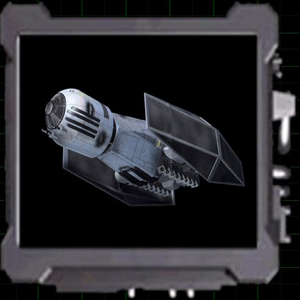

	 https://c8bc-34-181-158-66.ngrok-free.app/SWimagen  [ {'ngrok-skip-browser-warning': '69420'} - {'image': ('3778a817857b4565816311f48fbf6313.png', b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x01,\x08\x02\x00\x00\x00\xf6\x1f\x19"\x00\x01\x00\x00IDATx\x9c\xec\xfdy\x90fG\x92\x1f\x06\xba{D\xbc\xf7\xbe\xfb\xcb\xa3\xb2\xb2\xee\x03\x85\x1b\x8d\xab\x81>\xd0=\xdd=3\x9c\x19r8\xa4H\x1a\xc7HJ\xa4H\x8a2Q\xdc\x95d\xb2]\xb3\xfdw)\xdb5\xc9\x8ck\xb6\xab]\xed\x9a\xfe\x90-\xd7\xc4!5\xe4\x90\x94\xc8\xb9\x9bs\xb0{\xfa\x98\xbe\x80F7n\xa0PgV\xe5\x9d\xf9\x9d\xef\x8cp\xdf?\xe2\xbd\x97_f\x1d\x8d\x02\n=\rL\xba\xa1\xab\xf3;\xde\xfb\xe2E\x84\x87\xbb\xff\xfc\x02\xb8\x95\x10\x00\x01\x08H\x93\xd2\n\x15\x96\xef \x00@\x18\x06J\xd1m\xae\xaa\xafF@\x04\xa0\xf2\x12\x04BP\x80\x88\x01\x82\x81`1h\x1do\x02\x00\xa2FT\x88\n\x80\x00\x00\x11\xefr\xcf\x99\x9b#\x00\x84aHt\xb71\xdc\xe9\xa1\x105\x82R\xcb\xa8\xce\x12\x00B\xf9\x0f\xde\xd3\xbd\xea1\xbc\x971\xfbg\xf3?E\x00\x00Jc\x84@\xea\xa4\xa6\x93\xea\xde\x1e\xe1\x96aDQ

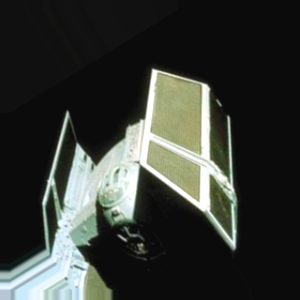

	 https://c8bc-34-181-158-66.ngrok-free.app/SWimagen  [ {'ngrok-skip-browser-warning': '69420'} - {'image': ('6804d5a4e72d4b38b03520232c0532bd.png', b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x01,\x08\x02\x00\x00\x00\xf6\x1f\x19"\x00\x00\xe5\xbcIDATx\x9c\xec\xfd\xe7\x97\x1cG\x92\'\x8a\x9ap\x8f\x88\xd4\x99\xa5\x05\x04\x05\xa8\xbbI6\xa7{\xa6G\xed\xee=w\xde}\xff\xf5\xbb\xf7\xbcs\xdf\xdd\xdd\x99\x1d\xd5\xd3jZP\x80\x90%SgF\xb8\x9b\xd9\xfb\xe0\x91E\x10(t\x83\x04@T\x91e\x87\xe4!\n\x19\x19Y\x19a\xe1\xe6f?\x81\xfd~\x1f\x9e;\x10\xf1\xb1\x9f\x98\xd9\xb3\x1dx\xce\xb1\x00`\xfa\xf8\xf1\xe7\xbe\xeci?>\xff\xec\x06\x06\x8f\xfe\x1c\x9fv\xf6\xa7\xc4\xe3\x9f\xe8\xfc\x17=\xdb/\xfeR\xe2\xf1_\xf0\xdb\xbe\x8d\x99\xaa\xaa\xea\xf3\xbf\xd5U<K\xd0\xab\xfe\x00Wq\x15?\xf4\xb8J\xc2\xab\xb8\x8aW\x1cWIx\x15W\xf1\x8a\xe3*\t\xaf\xe2*^q\\%\xe1U\\\xc5+\x8e\xab$\xbc\x8a\xabx\xc5q\x95\x84Wq\x15\xaf8\xae\x92\xf0*\xae\xe2\x15\xc7U\x12^\xc5U\xbc\xe2x1I\xf8$J\x04\x9f\x02(y\xe2\xc8s\x8e\x05\x00xV\x08\xce\xf9\x10\

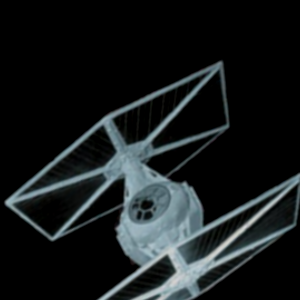

	 https://c8bc-34-181-158-66.ngrok-free.app/SWimagen  [ {'ngrok-skip-browser-warning': '69420'} - {'image': ('746b6f9e89904945bb8731e585d80723.png', b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x01,\x08\x02\x00\x00\x00\xf6\x1f\x19"\x00\x00\xf1<IDATx\x9c\xec\xfd\xe7\x9a\x1c\xc7\xb5\xae\x8b\x8e\x11&}\x96w\xed=@Ps\xcd\xbd\xf7\xfd_\xc4Yk\x89$\xbci[\xde\xa4wa\xce\x8f\xac\x06\x01\x8a\xe2\x94(Z\xb0^Q\x8f \xb0\xbb*\xb3;\xbf\x8a\x88a\xbe\x01\xb0c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\x8e\x1d;v\xec\xd8\xb1c\xc7\

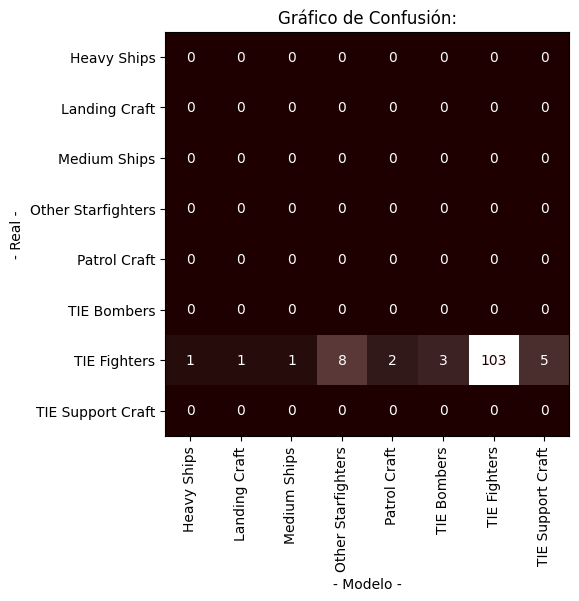

In [ ]:
# @title Probar Web API remota para Imágenes {"single-column":true}

import ipywidgets as widgets
from ipywidgets import Box, Layout
from IPython.display import clear_output
import random
import time
from PIL import Image

import json
import requests

ngrok_public_Web_API_imagenes = "https://c8bc-34-181-158-66.ngrok-free.app/SWimagen" #@param{type:"string"}


strAZAR = "-AZAR-"
path_imagenes = "/content/gdrive/MyDrive/demosColab/demoStarWars/imagenes"  #@param {type:"string"}

# función auxiliar para ejecutar la web API usando request
def ejecutarModelWebAPI_imagenes(imageFN, URL_API, mostrarDetalle=False):
  # prepara la info de la imagen a mandar como archivo
  data_json = {'image': (os.path.basename(imageFN),
                          open(imageFN, "rb").read(),
                          #'multipart/form-data',
                           {'Expires': '0'}) }
  headers = {"ngrok-skip-browser-warning": "69420" }
  if mostrarDetalle:
    print("\t", URL_API, " [", headers, "-", data_json, "]")
  json_response = requests.post(URL_API, files=data_json, headers=headers)
  if json_response.status_code == 200:
    res = json.loads(json_response.text)
    if mostrarDetalle:
      print("\t", json_response, "-", res)
    if ("data" in res):
      return res["data"]
    else:
      return None
  else:
    if mostrarDetalle:
      print("\t", json_response, ":", json_response.content)
    return None

# función auxiliar para procesar una imagen
def procesarImagen(imageFN, datosClaseReal, mostrarDetalle=True):
  if mostrarDetalle:
    print("\n> Imagen: ", imageFN)
    display( Image.open(imageFN) )
  # ejecuta API
  resAPI = ejecutarModelWebAPI_imagenes(imageFN, ngrok_public_Web_API_imagenes, mostrarDetalle)
  if resAPI is None:
    claseModelo = None
    evalRes = ""
  else:
    claseModelo = resAPI["clase"]
    evalRes = "--> " + ("OK" if (claseModelo == datosClaseReal) else "ERROR!")
  if mostrarDetalle:
    print("* Resultado API: ",  resAPI, evalRes)
    print("")
  return datosClaseReal, claseModelo

# función auxiliara para que no ejecute UI cada vez
def hacerNada():
  return

def definirImagsClaseProcesar():
  # determina directorio
  if combo_clase.value==strAZAR:
    combo_clase_dir = random.choice(all_image_classes[0:-1])
    print("* Elige al azar clase: ", combo_clase_dir)
  else:
    combo_clase_dir = combo_clase.value
  class_path = path_imagenes + "/" + path_imagenes_tipo.value + "/" + combo_clase_dir
  # carga imagenes disponibles
  images_in_class_path = os.listdir( class_path )
  images_in_class_path = [ class_path + "/" + fn for fn in images_in_class_path
                          if ( fn.endswith('.png') or fn.endswith('.jpg') or fn.endswith('.jpeg') ) ]
  return images_in_class_path, combo_clase_dir

# se define esta función para solicite procesar un ejemplo al azar
def on_btnEnviarImagAzar_clicked(b):
  print("")
  # obtiene imagenes y elige una al azar
  images_in_class_path, claseSel = definirImagsClaseProcesar()
  imageFN = random.choice(images_in_class_path)
  # procesa la imagen
  procesarImagen(imageFN, claseSel, mostrarDetalle=True)

# se define esta función para solicite procesar todos los ejemplos
def on_btnEnviarImagTodas_clicked(b):
  print("")
  # obtiene imagenes
  images_in_class_path, claseSel = definirImagsClaseProcesar()
  print("Procesando imágenes...")
  clases_REAL = []
  clases_MODELO = []
  # itera todas las imagenes
  for imageFN in images_in_class_path:
    # le da un toque para que el servidor descanse
    time.sleep(0.5)
    # procesa la imagen
    clReal, clModelo = procesarImagen(imageFN, claseSel, mostrarDetalle=False)
    # registra resultado
    clases_REAL.append(clReal)
    if clModelo is None:
      clases_MODELO.append("NA")
    else:
      clases_MODELO.append(clModelo)
  # muestra reporte de clasificación
  print("")
  generaResumen_Clasificacion(clases_REAL, clases_MODELO)
  return

# permite seleccionar una clase y toma una imagen al azar
subdirs = list( os.listdir(path_imagenes) )
subdirs.sort()
path_imagenes_tipo = widgets.Dropdown(
    options = subdirs,
    value = subdirs[0],
    description = "Tipo path imágenes:",
    disabled = False,
    style= {'description_width': 'initial', 'width': 'initial'}
)
all_image_classes = os.listdir( path_imagenes + "/" + path_imagenes_tipo.value )
all_image_classes.append( strAZAR )
combo_clase = widgets.Dropdown(
    options = all_image_classes,
    description = 'Clase a procesar:',
    value = strAZAR,
    disabled = False,
    style= {'description_width': 'initial', 'width': 'initial'}
)
# prepara botón y grilla con objetos
btnEnviarImagAzar = widgets.Button(
    description='Enviar al Azar'
)
btnEnviarImagTodas = widgets.Button(
    description='Enviar Todas'
)
configDatos_ui = widgets.GridBox(
      children=[ path_imagenes_tipo, combo_clase, btnEnviarImagAzar, btnEnviarImagTodas],
      layout=Layout(width='100%')  )
btnEnviarImagAzar.on_click(on_btnEnviarImagAzar_clicked)
btnEnviarImagTodas.on_click(on_btnEnviarImagTodas_clicked)

#clear_output()
out_config = widgets.interactive_output(hacerNada, {})
display(configDatos_ui)
